In [1]:
import warnings
from importlib.util import find_spec

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor.tensor as pt
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior
from scipy.stats import Normal

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.mmm import MMM

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

seed: int = sum(map(ord, "mmm"))
rng: np.random.Generator = np.random.default_rng(seed=seed)


def get_nuts_sampler():
    """Use a JAX sampler when available, otherwise fall back to PyMC NUTS."""
    for sampler in ("nutpie", "numpyro", "blackjax"):
        if find_spec(sampler) is not None:
            return sampler
    return "pymc"


%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

# ROAS uncertainty after one lift test

This notebook asks a narrow question: **how much would one lift test reduce uncertainty in a channel's ROAS estimate?**

We first fit a standard Marketing Mix Model (MMM), following the PyMC-Marketing [MMM End-to-End Case Study](https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_case_study.html). The plots below show weekly media spend and sales; gray sales are the held-out period.

In [2]:
# Demo data used in the PyMC-Marketing MMM case study.
raw_df = pd.read_csv("https://raw.githubusercontent.com/sibylhe/mmm_stan/main/data.csv")

# Controls: keep only holiday indicators.
control_columns = [col for col in raw_df.columns if "hldy_" in col]

# Media: use a small set of channels with readable names.
channel_columns_raw = sorted(
    [
        col
        for col in raw_df.columns
        if "mdsp_" in col
        and col != "mdsp_viddig"
        and col != "mdsp_auddig"
        and col != "mdsp_sem"
    ]
)

channel_mapping = {
    "mdsp_dm": "Direct Mail",
    "mdsp_inst": "Insert",
    "mdsp_nsp": "Newspaper",
    "mdsp_audtr": "Radio",
    "mdsp_vidtr": "TV",
    "mdsp_so": "Social Media",
    "mdsp_on": "Online Display",
}

channel_columns = sorted(list(channel_mapping.values()))
n_channels = len(channel_columns)
sales_col = "sales"

data_df = raw_df[["wk_strt_dt", sales_col, *channel_columns_raw, *control_columns]]
data_df = data_df.rename(columns=channel_mapping)

data_df["wk_strt_dt"] = pd.to_datetime(data_df["wk_strt_dt"])
date_column = "wk_strt_dt"
target_column = "sales"

# Fit on the historical period, then use the held-out period for display.
train_test_split_date = pd.to_datetime("2018-02-01")

train_mask = data_df.wk_strt_dt <= train_test_split_date
test_mask = data_df.wk_strt_dt > train_test_split_date

train_df = data_df[train_mask]
test_df = data_df[test_mask]

X_train = train_df.drop(columns=sales_col)
y_train = train_df[sales_col]

<Axes: xlabel='wk_strt_dt', ylabel='sales'>

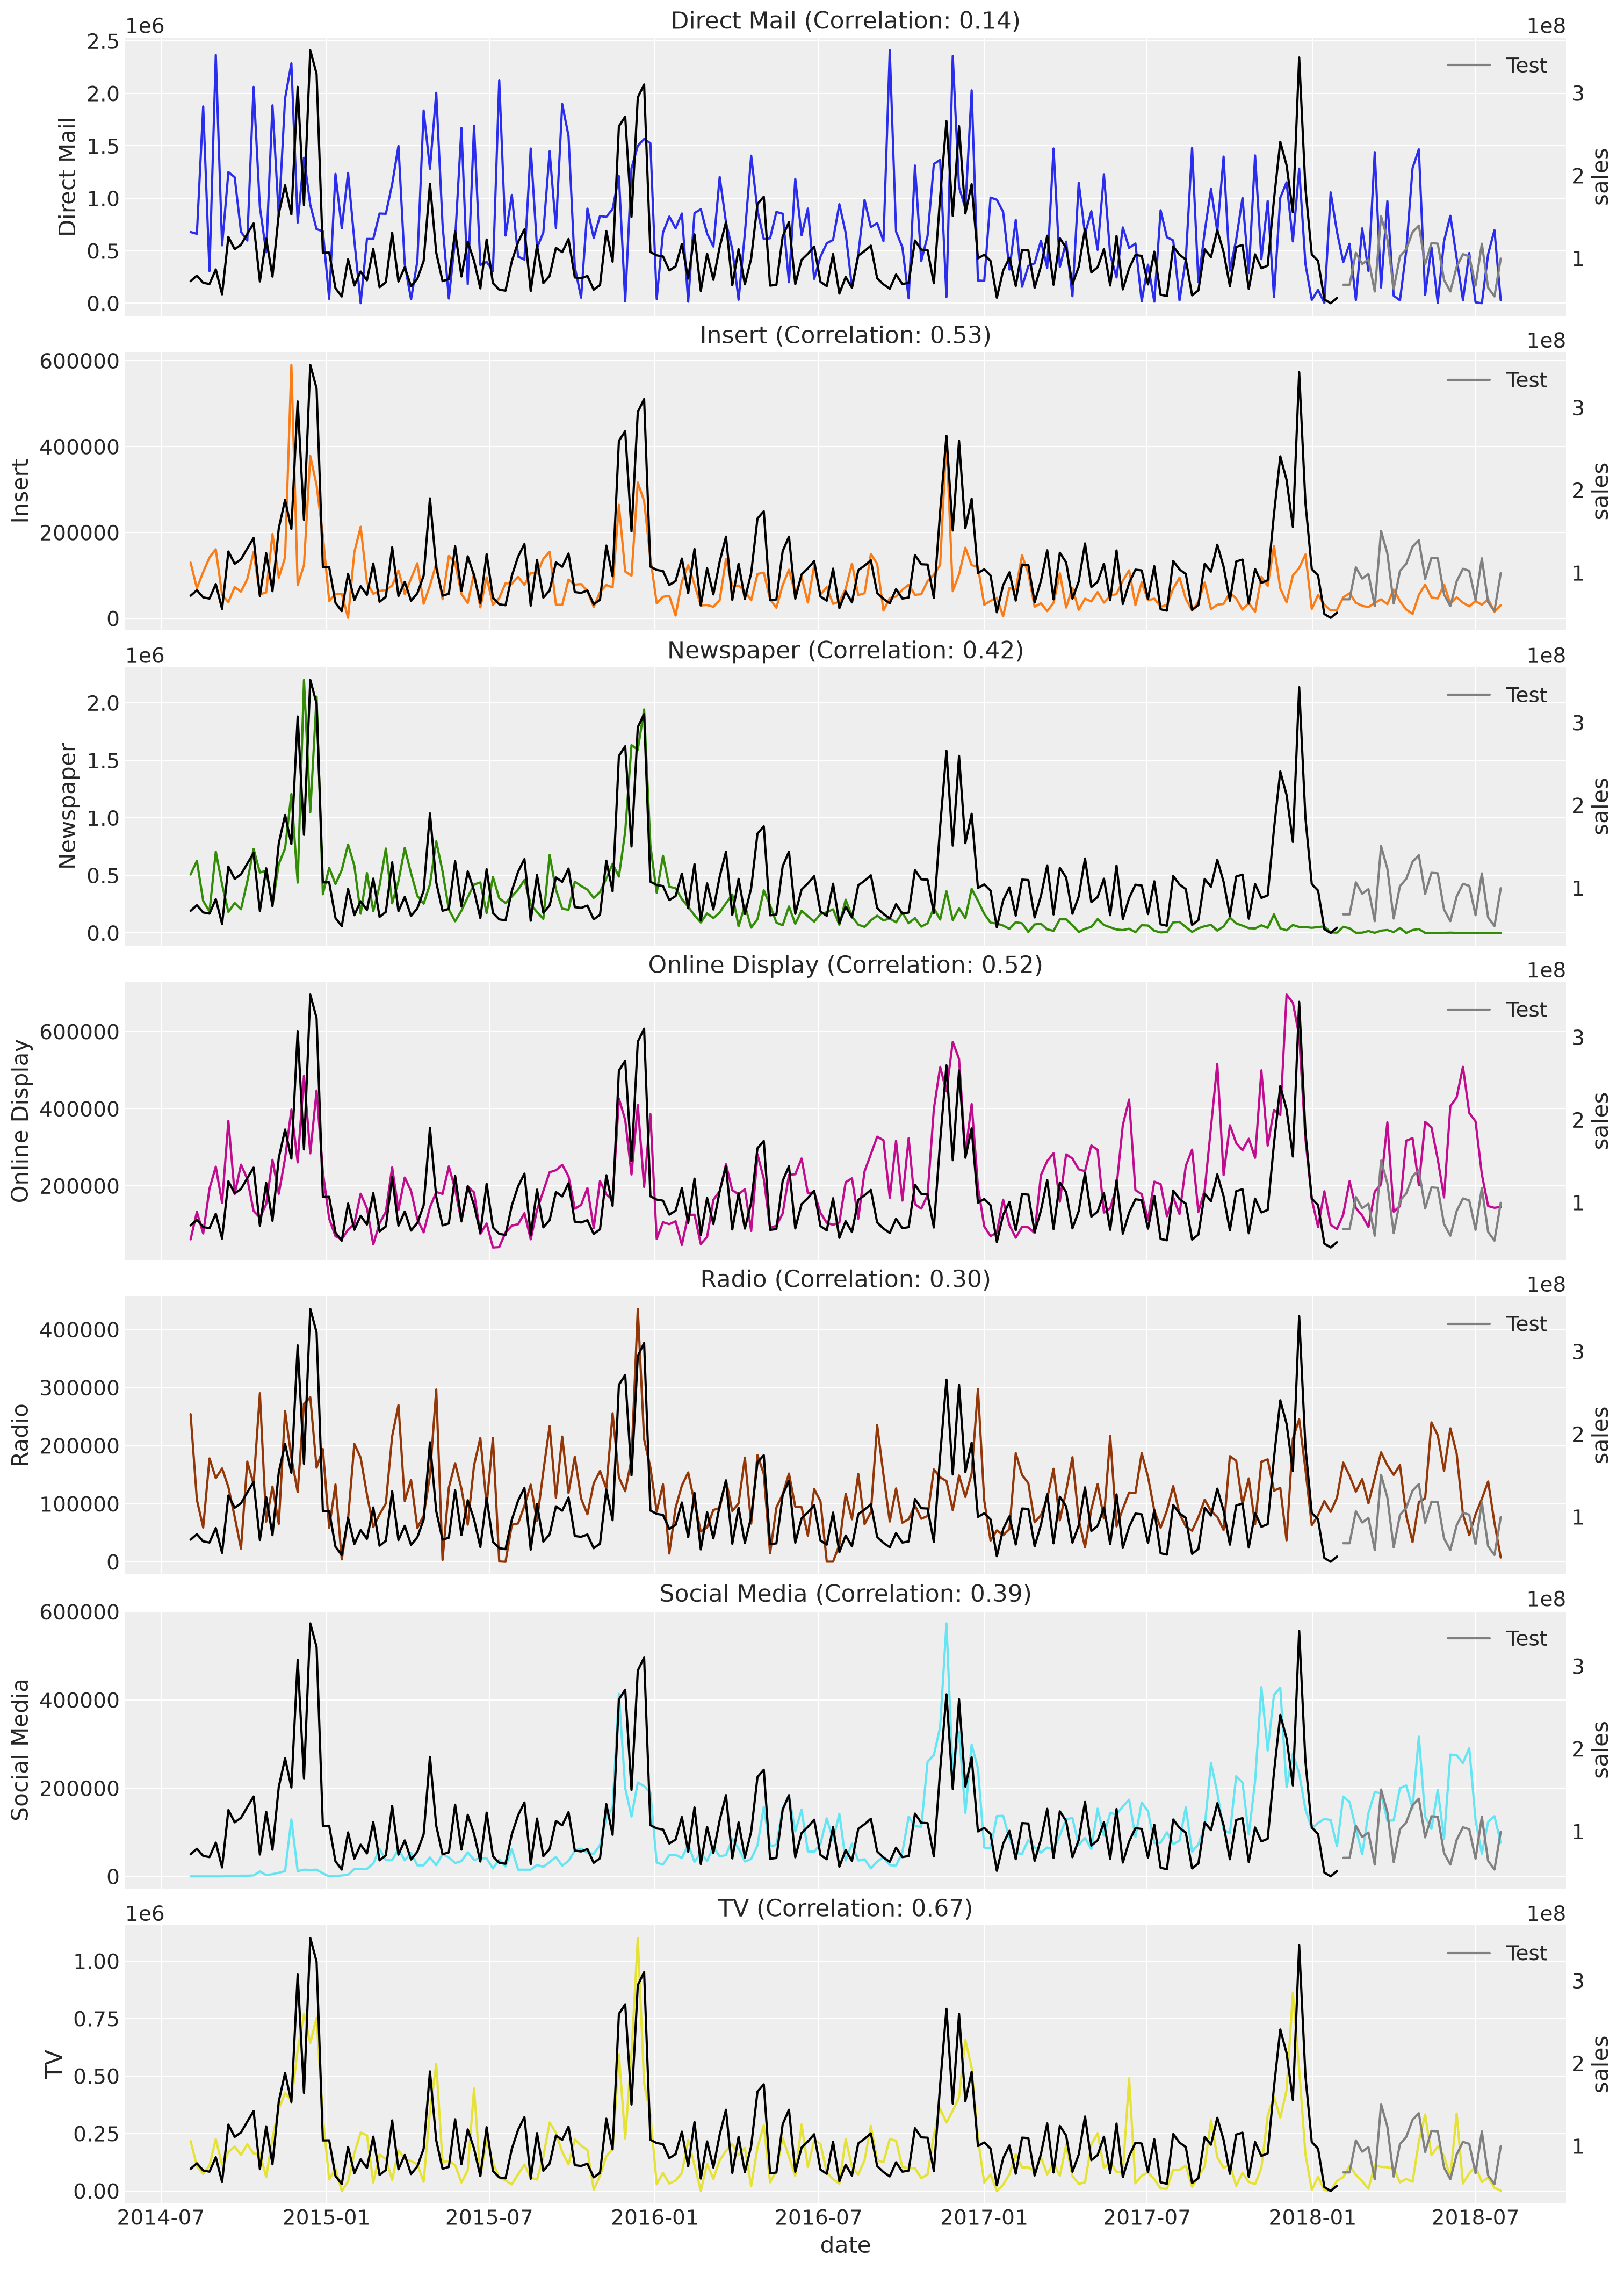

In [3]:
_fig, _axes = plt.subplots(
    nrows=n_channels,
    ncols=1,
    figsize=(15, 3 * n_channels),
    sharex=True,
    sharey=False,
    layout="constrained",
)

for i, channel in enumerate(channel_columns):
    _ax = _axes[i]
    _ax_twin = _ax.twinx()
    sns.lineplot(data=data_df, x=date_column, y=channel, color=f"C{i}", ax=_ax)
    sns.lineplot(
        data=train_df,
        x=date_column,
        y=sales_col,
        color="black",
        ax=_ax_twin,
    )
    sns.lineplot(
        data=test_df,
        x=date_column,
        y=sales_col,
        color="gray",
        label="Test",
        ax=_ax_twin,
    )
    correlation = train_df[[channel, sales_col]].corr().iloc[0, 1]
    _ax_twin.grid(None)
    _ax.set(title=f"{channel} (Correlation: {correlation:.2f})")

_ax.set_xlabel("date")
plt.gca()

We fit the MMM with adstock, saturation, holiday controls, and yearly seasonality. The sampler budget is intentionally generous for a demo so the later ROAS uncertainty comparison is not dominated by MCMC noise.

In [4]:
spend_shares = (
    X_train.melt(value_vars=channel_columns, var_name="channel", value_name="spend")
    .groupby("channel", as_index=False)
    .agg({"spend": "sum"})
    .sort_values(by="channel")
    .assign(spend_share=lambda x: x["spend"] / x["spend"].sum())["spend_share"]
    .to_numpy()
)

prior_sigma = spend_shares

model_config = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.05),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=1, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
    "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1)),
}

sampler_config = {"progressbar": True}

mmm = MMM(
    model_config=model_config,
    sampler_config=sampler_config,
    target_column=target_column,
    date_column=date_column,
    adstock=GeometricAdstock(l_max=6),
    saturation=LogisticSaturation(),
    channel_columns=channel_columns,
    control_columns=control_columns,
    yearly_seasonality=5,
)

mmm.build_model(X_train, y_train)

# Add the contribution variables to the model
# to track them in the model and trace.
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

nuts_sampler = get_nuts_sampler()
fit_kwargs = {"nuts_sampler": nuts_sampler}
if nuts_sampler == "nutpie":
    fit_kwargs["nuts_sampler_config"] = {
        "adaptation": "low_rank",
        "backend": "jax",
    }

mmm.fit(
    X=X_train,
    y=y_train,
    chains=6,
    cores=6,
    tune=1000,
    draws=1000,
    random_seed=rng,
    **fit_kwargs,
)

mmm.plot_suite = "new"

/home/teemu/pymc-labs/worktrees/pymc-marketing/case-study/lift-test-roas-information/.venv/lib/python3.13/site-packages/pymc_extras/prior.py:851: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (6 chains in 6 jobs)
NUTS: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Sampling 6 chains for 1_000 tune and 1_000 draw iterations (6_000 + 6_000 draws total) took 23 seconds.


Output()

/home/teemu/pymc-labs/worktrees/pymc-marketing/case-study/lift-test-roas-information/.venv/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


The diagnostics are healthy: worst r-hat is below 1.01 and ESS is above 500 for all parameters.

In [5]:
az.summary(
    mmm.idata,
    var_names=[var.name for var in mmm.model.free_RVs],
    kind="diagnostics",
).sort_values("r_hat", ascending=False)

,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept_contribution,2686,3436,1.00,0.00057,0.00042
gamma_control[hldy_Thanksgiving],4319,3892,1.00,0.012,0.0088
gamma_control[hldy_Green Monday],4432,4328,1.00,0.0011,0.00081
gamma_control[hldy_July 4th],4468,4147,1.00,0.0012,0.00088
gamma_control[hldy_Labor Day],5820,4433,1.00,0.00083,0.0006
gamma_control[hldy_MLK],5469,4188,1.00,0.00097,0.00071
gamma_control[hldy_Memorial Day],5116,4680,1.00,0.001,0.00073
gamma_control[hldy_Mother's Day],4748,4233,1.00,0.0011,0.00083
gamma_control[hldy_NYE],3335,3779,1.00,0.0018,0.0013
gamma_control[hldy_New Year's Day],3548,3987,1.00,0.0016,0.0012


## Simulating one lift test

A lift test observes the incremental sales from increasing spend on one channel. We simulate many possible lift-test outcomes from the fitted MMM, then reweight the posterior by how compatible each draw is with that single observation.

The result is a distribution of **ROAS standard-deviation reduction**: how much narrower the ROAS posterior could become after one test.

In [6]:
def compile_saturation_fn(mmm):
    """Compile and cache the channel saturation curve for fast lift simulations."""
    if hasattr(mmm.saturation, "_compiled_fn"):
        return mmm.saturation._compiled_fn
    import inspect

    import pytensor
    import pytensor.xtensor as ptx

    sig = inspect.signature(mmm.saturation.function)
    param_names = [
        p.name
        for p in sig.parameters.values()
        if p.name not in ("x", "dim") and p.default == inspect.Parameter.empty
    ]
    x = ptx.as_xtensor(pt.vector("x"), dims=("x",))
    inputs = [x]
    param_tensors = []
    for name in param_names:
        var_name = mmm.saturation.variable_mapping[name]
        arr = mmm.idata["posterior"][var_name]
        ndim = arr.ndim
        dims = tuple(arr.dims)
        if ndim == 0:
            tensor = pt.scalar(name)
        elif ndim == 1:
            tensor = pt.vector(name)
        elif ndim == 2:
            tensor = pt.matrix(name)
        elif ndim == 3:
            tensor = pt.tensor3(name)
        else:
            tensor = pt.TensorType("float64", [False] * ndim)(name)
        xtensor_var = ptx.as_xtensor(tensor, dims=dims)
        param_tensors.append(xtensor_var)
        inputs.append(tensor)
    out = mmm.saturation.function(x, *param_tensors)
    fn = pytensor.function(inputs, out)
    mmm.saturation._compiled_fn = fn
    return fn

In [7]:
def sample_lift_experiments(
    n_experiments, x_start, x_end, lift_test_sigma, mmm, channel_name
):
    """Simulate possible one-test outcomes and their posterior weights.

    Each experiment chooses one posterior draw as the temporary ``truth``. The
    observed lift is that draw's lift plus test noise. PSIS weights then
    approximate the posterior after seeing that one noisy result.
    """
    import inspect

    x_max = x_end / mmm.scalers._channel.sel(channel=channel_name)
    x_min = x_start / mmm.scalers._channel.sel(channel=channel_name)
    sat_fn = compile_saturation_fn(mmm)

    sig = inspect.signature(mmm.saturation.function)
    param_names = [
        p.name
        for p in sig.parameters.values()
        if p.name not in ("x", "dim") and p.default == inspect.Parameter.empty
    ]
    channel_idx = list(mmm.idata["posterior"].coords["channel"].values).index(
        channel_name
    )

    # Cache the full posterior lift vector once (shared by all experiments)
    if "lift" not in mmm.idata["posterior"].data_vars:
        param_vals_full = [
            mmm.idata["posterior"][mmm.saturation.variable_mapping[name]].values
            for name in param_names
        ]
        lift_max = sat_fn(np.array([x_max]), *param_vals_full).squeeze(axis=-1)
        lift_min = sat_fn(np.array([x_min]), *param_vals_full).squeeze(axis=-1)
        lift_values = (lift_max - lift_min)[:, :, channel_idx]

        mmm.idata["posterior"]["lift"] = xr.DataArray(
            data=lift_values,
            dims=["chain", "draw"],
            coords={
                "chain": mmm.idata["posterior"].coords["chain"],
                "draw": mmm.idata["posterior"].coords["draw"],
            },
        )

    lift = mmm.idata["posterior"]["lift"]
    n_chains, n_draws = lift.shape
    sigma = lift_test_sigma / mmm.scalers._target.values

    experiments = []
    for _ in range(n_experiments):
        chain_i = int(rng.integers(0, n_chains))
        draw_i = int(rng.integers(0, n_draws))
        true_lift = float(lift.values[chain_i, draw_i])
        lift_obs = float(rng.normal(loc=true_lift, scale=sigma))

        lw, k_hat = az.base.array_stats.psislw(
            -Normal(mu=lift_obs, sigma=sigma).logpdf(lift.values)
        )
        experiments.append(
            {
                "chain": chain_i,
                "draw": draw_i,
                "lift_obs": lift_obs,
                "weights": np.exp(lw),
                "k_hat": float(k_hat[0]),
            }
        )
    return experiments

In [8]:
def resample_posterior(idata, weights, num_samples=500):
    """Draw a weighted posterior sample after a simulated lift test."""
    posterior = idata["posterior"]
    n_chains = posterior.sizes["chain"]
    n_draws = posterior.sizes["draw"]
    flat_weights = np.asarray(weights).flatten()
    flat_weights = flat_weights / flat_weights.sum()

    idx = rng.choice(
        n_chains * n_draws,
        size=num_samples,
        p=flat_weights,
        replace=True,
    )
    chain_idx = idx // n_draws
    draw_idx = idx % n_draws

    resampled_vars = {}
    for var in posterior.data_vars:
        da = posterior[var]
        extra_dims = [d for d in da.dims if d not in ("chain", "draw")]
        indexed = da.values[chain_idx, draw_idx]
        # Reshape to (1, num_samples, ...) for consistent chain/draw structure
        reshaped = indexed.reshape((1, num_samples, *indexed.shape[1:]))
        coords = {"chain": [0], "draw": range(num_samples)}
        for d in extra_dims:
            coords[d] = da.coords[d].values
        resampled_vars[var] = xr.DataArray(
            reshaped,
            dims=["chain", "draw", *extra_dims],
            coords=coords,
        )
    resampled = xr.Dataset(resampled_vars)
    out = xr.DataTree.from_dict({"posterior": resampled})
    out.attrs = getattr(idata, "attrs", {}).copy()
    return out

Choose the channel, test spend range, and assumed lift-test noise. Lower test sigma means a more precise experiment.

In [9]:
channel_selection = "Online Display"
test_budget = 50_000
start_spend = 50_000
test_sigma = 1_000_000

In [10]:
# Draw many possible one-test outcomes for the selected channel.
experiments = sample_lift_experiments(
    1000,
    start_spend,
    start_spend + test_budget,
    test_sigma,
    mmm,
    channel_selection,
)

In [11]:
# ROAS per posterior draw: total channel contribution divided by spend.
mmm.idata["posterior"]["ROAS"] = mmm.idata["posterior"][
    "channel_contribution_original_scale"
].sum("date") / mmm.idata["constant_data"]["channel_data"].sum("date")

In [12]:
# For each simulated lift test, estimate the posterior ROAS uncertainty.
stds = [
    resample_posterior(mmm.idata, e["weights"])["posterior"]["ROAS"].std(
        ["chain", "draw"]
    )
    for e in experiments
]

The next plot is the current ROAS posterior before running a lift test.

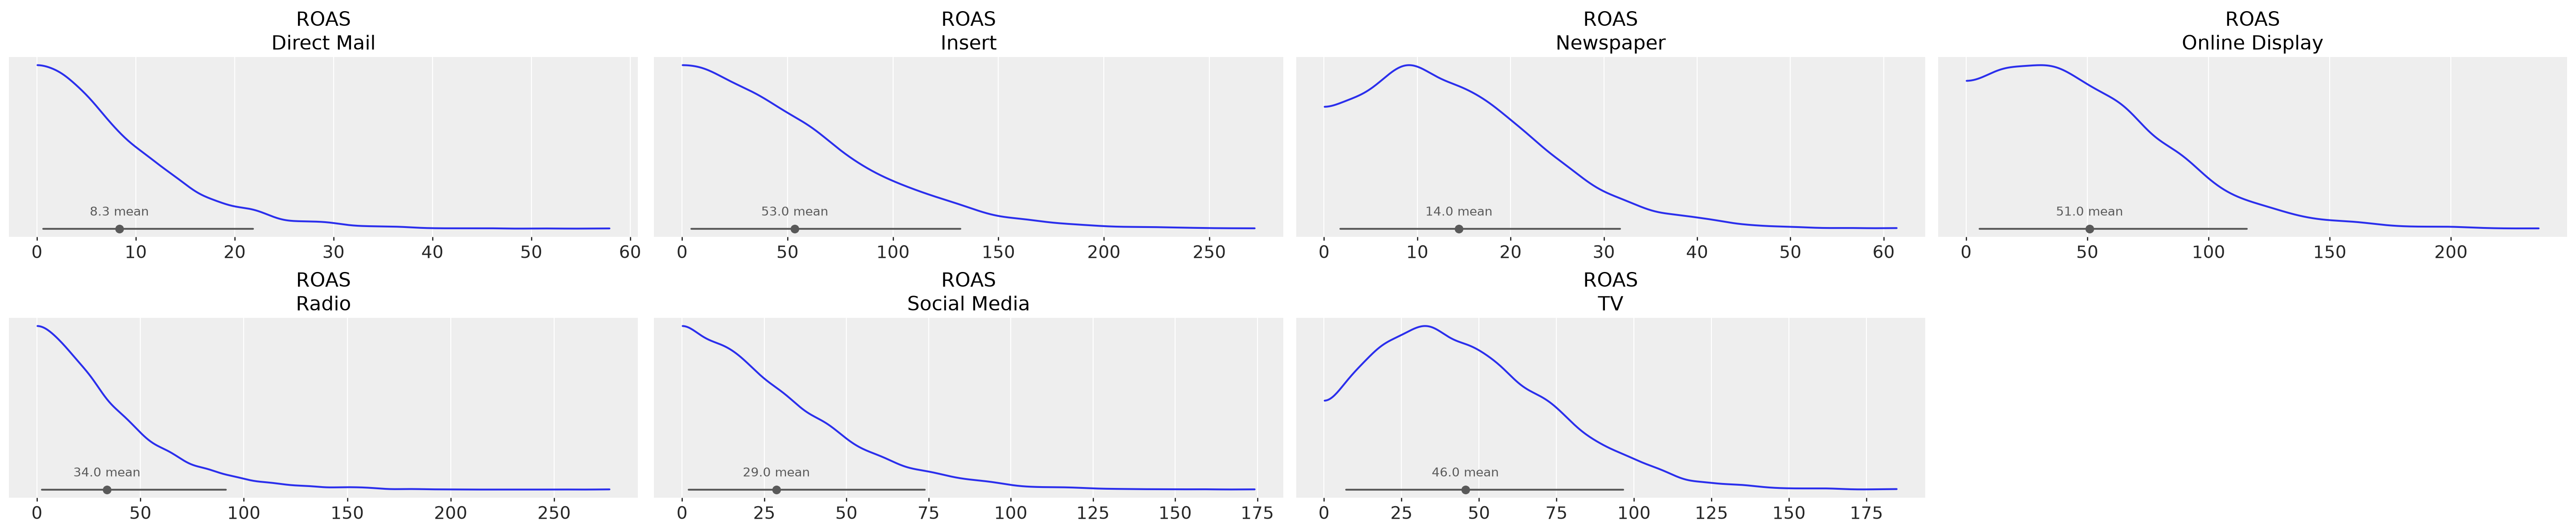

In [13]:
az.plot_dist(mmm.idata, var_names=["ROAS"])

Finally, we compare current ROAS uncertainty to the reweighted posterior after each simulated lift test. Values farther above zero mean the single test would reduce ROAS uncertainty more.

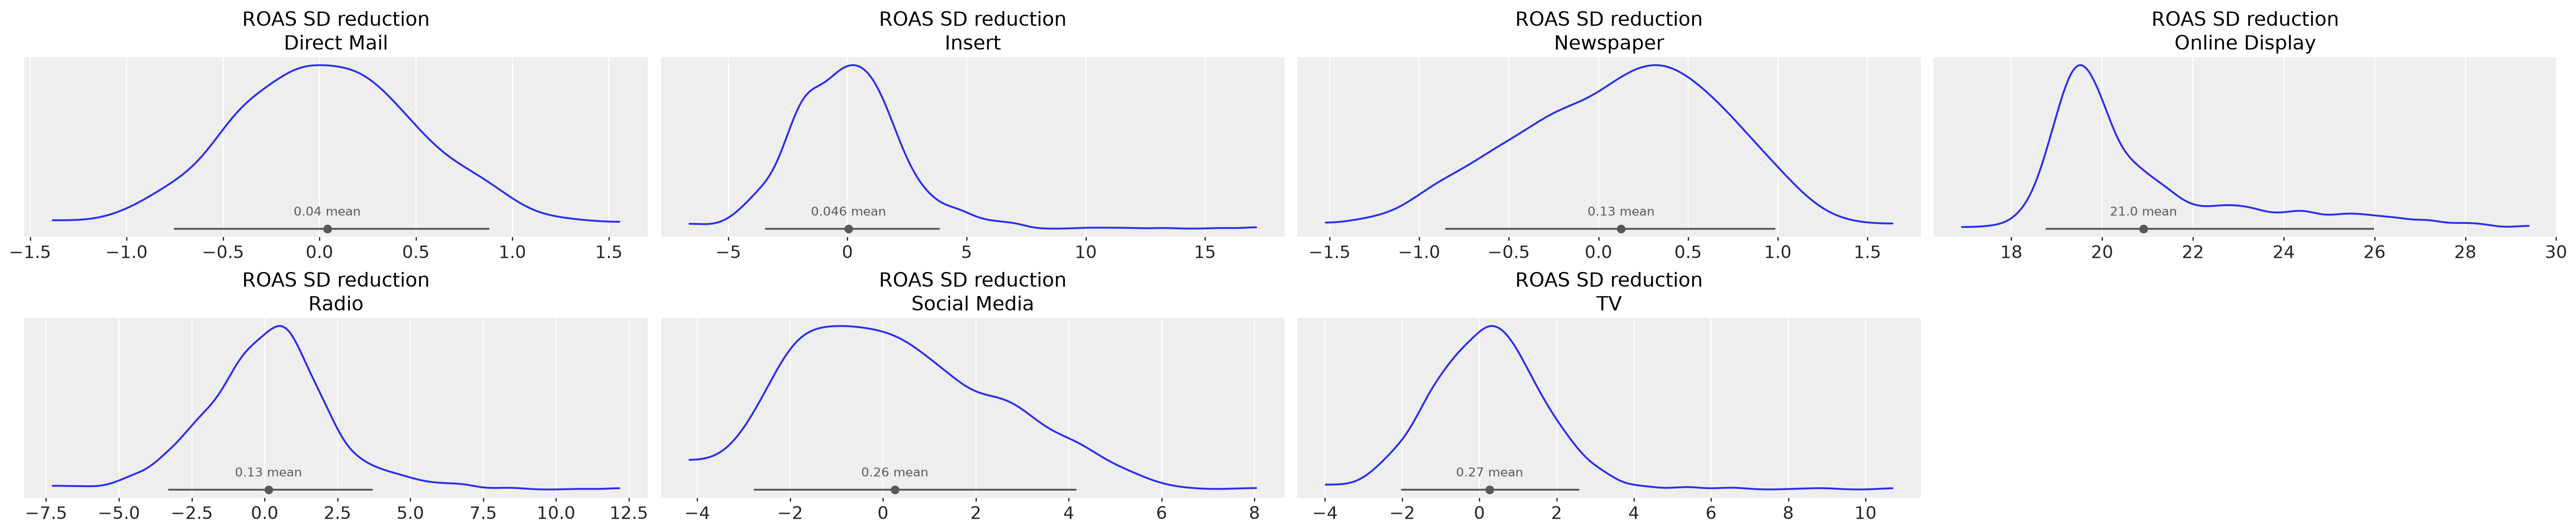

In [14]:
roas_sd_reduction = mmm.idata["posterior"]["ROAS"].std(["chain", "draw"]) - xr.concat(
    stds, dim="test"
)

az.plot_dist(
    xr.Dataset({"ROAS SD reduction": roas_sd_reduction}),
    sample_dims="test",
)

In [15]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

ModuleNotFoundError: No module named 'watermark'

In [ ]:
! uv 